In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_12_png.rf.566726d03bb59741293c5a5c58d71f5e_aug_2.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_45_png.rf.7b0c39c7948b368961c4bbc376c93d99.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_43_png.rf.225187fb6b8111d171ffcccb2e905e3a_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_50_png.rf.15b257af83325aa3721cf4463a3ce1b8_aug_1.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_47_png.rf.96ba9988494f51b9f661609792706976_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_24_png.rf.8e55a751c663f1c4fb91639

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import copy
import os

# -----------------------
# Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------
# Config
# -----------------------
num_classes = 5
batch_size = 16
num_epochs_stage1 = 10
num_epochs_stage2 = 30
patience = 7

# -----------------------
# Data Transforms
# -----------------------

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05),
        scale=(0.9,1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------
# Load Dataset
# -----------------------

train_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/stage2/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/stage2/valid",
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/prasadmalaiiiitk/sem-data02/sem-dataset/stage2/test",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# -----------------------
# Compute Class Weights
# -----------------------

class_counts = np.bincount(train_dataset.targets)
total_samples = sum(class_counts)

class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# -----------------------
# Load Pretrained EfficientNet
# -----------------------

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

# -----------------------
# Stage 1: Freeze Backbone
# -----------------------

for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3
)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0
trigger_times = 0

# -----------------------
# Training Function
# -----------------------

def train_model(num_epochs):
    global best_acc, best_model_wts, trigger_times

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- Training ----
        model.train()
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = correct / total
        print("Train Accuracy:", train_acc)

        # ---- Validation ----
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = correct / total
        print("Validation Accuracy:", val_acc)

        scheduler.step(val_acc)

        # Early Stopping
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered")
                break

# -----------------------
# Run Stage 1
# -----------------------
print("\nStage 1: Training Classifier Only")
train_model(num_epochs_stage1)

# -----------------------
# Stage 2: Fine-Tuning
# -----------------------
print("\nStage 2: Fine-Tuning Full Network")

for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3
)

train_model(num_epochs_stage2)

# -----------------------
# Load Best Model
# -----------------------
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "best_efficientnet_model.pth")

print("\nBest Validation Accuracy:", best_acc)

# -----------------------
# Test Evaluation
# -----------------------

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Using device: cpu

Stage 1: Training Classifier Only

Epoch 1/10
Train Accuracy: 0.6696252465483234
Validation Accuracy: 0.6721311475409836

Epoch 2/10
Train Accuracy: 0.8451676528599605
Validation Accuracy: 0.7377049180327869

Epoch 3/10
Train Accuracy: 0.8422090729783037
Validation Accuracy: 0.6721311475409836

Epoch 4/10
Train Accuracy: 0.8717948717948718
Validation Accuracy: 0.6885245901639344

Epoch 5/10
Train Accuracy: 0.8816568047337278
Validation Accuracy: 0.7377049180327869

Epoch 6/10
Train Accuracy: 0.8925049309664694
Validation Accuracy: 0.7049180327868853

Epoch 7/10
Train Accuracy: 0.893491124260355
Validation Accuracy: 0.6557377049180327

Epoch 8/10
Train Accuracy: 0.883629191321499
Validation Accuracy: 0.6557377049180327

Epoch 9/10
Train Accuracy: 0.8974358974358975
Validation Accuracy: 0.7049180327868853
Early stopping triggered

Stage 2: Fine-Tuning Full Network

Epoch 1/30
Train Accuracy: 0.8964497041420119
Validation Accuracy: 0.7704918032786885

Epoch 2/30
Train A

In [6]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc": best_acc,
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

torch.save(checkpoint, "efficientnet_b0_sem_defect.pth")

print("Model saved successfully!")

Model saved successfully!


In [7]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

device = torch.device("cpu")

num_classes = 5   # or load from checkpoint

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

checkpoint = torch.load("efficientnet_b0_sem_defect.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [11]:
!pip install -U onnx onnxscript

import onnxscript
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "efficientnet_b0_sem_defect.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"},
                  "output": {0: "batch_size"}},
    opset_version=11
)

print("ONNX model exported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 10.4 MB/s eta 0:00:00


/tmp/ipykernel_55/244426148.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0301 08:01:41.862000 55 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0301 08:01:42.765000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

Applied 98 of general pattern rewrite rules.
ONNX model exported successfully!


In [12]:
example_input = torch.randn(1, 3, 224, 224)

traced_model = torch.jit.trace(model, example_input)
traced_model.save("efficientnet_b0_sem_defect.pt")

print("TorchScript model saved!")

TorchScript model saved!


In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [15]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Classification report as dictionary
report = classification_report(all_labels, all_preds, output_dict=True)

# Extract per-class F1 scores
num_classes = len(train_dataset.classes)
f1_scores = [report[str(i)]['f1-score'] for i in range(num_classes)]

print("Accuracy:", accuracy)
print("F1 Scores:", f1_scores)

Accuracy: 0.7647058823529411
F1 Scores: [0.8695652173913043, 0.8888888888888888, 0.9090909090909091, 0.6857142857142857, 0.5517241379310345]


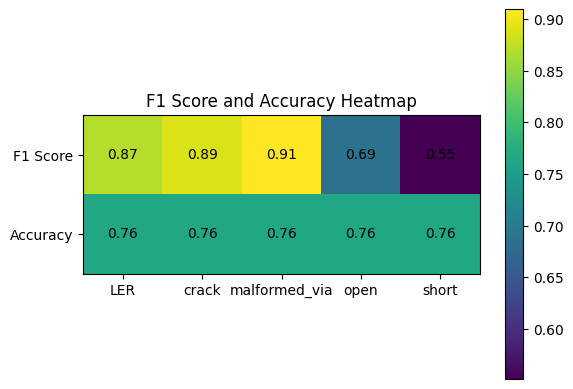

In [16]:
import matplotlib.pyplot as plt

# Create heatmap matrix
heatmap_data = np.array([
    f1_scores,
    [accuracy] * num_classes
])

plt.figure()
plt.imshow(heatmap_data)

plt.xticks(range(num_classes), train_dataset.classes)
plt.yticks([0,1], ["F1 Score", "Accuracy"])

# Add text inside cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(j, i, round(heatmap_data[i, j], 2),
                 ha="center", va="center")

plt.title("F1 Score and Accuracy Heatmap")
plt.colorbar()
plt.show()